# STATE SE — Larry 46k cells, quality 1.0

Prepare data, train, embed, and compute LMI (clone signal).

In [1]:
import sys, os
sys.path.insert(0, os.path.expanduser(
    "~/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/scaling_laws/src"
))

from pathlib import Path
import glob
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import umap

from scaling_laws.prepare.data import Experiments, PrepareData
from scaling_laws.algo import State

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path(os.path.expanduser("~/noise_scaling/data"))
DATASET = "larry"
SIZE = 46_415
QUALITY = 1.0
DEVICE = 3
SEED = 42

In [3]:
# --- Gene count check: raw dataset vs ESM embeddings ---
import torch

raw_path = DATA_DIR / DATASET / "raw" / "raw.h5ad"
adata_raw = ad.read_h5ad(raw_path, backed="r")
raw_genes = set(adata_raw.var_names)
n_raw = len(raw_genes)
adata_raw.file.close()

esm_emb = torch.load(DATA_DIR / "other" / "esm" / "merged_esm_embeddings.pt", map_location="cpu")
esm_genes = set(esm_emb.keys())
n_esm = len(esm_genes)
del esm_emb

overlap = len(raw_genes & esm_genes)
print(f"{DATASET}: {overlap}/{n_raw} raw genes found in ESM ({100*overlap/n_raw:.1f}%), ESM total: {n_esm}")

larry: 18146/25289 raw genes found in ESM (71.8%), ESM total: 61260


## 1. Prepare STATE data

Run `state emb preprocess` to build the gene-embedding profile.

In [4]:
experiments = Experiments(
    path_to_data_dir=str(DATA_DIR),
    datasets=[DATASET],
    qualities=[QUALITY],
    sizes=[SIZE],
    algos=["State"],
    signal_columns=["clone"],
    device=DEVICE,
)

experiments.prepare_state_data()

  Using ESM embeddings: /home/igor/noise_scaling/data/other/esm/merged_esm_embeddings.pt

=== Preparing State data for larry / 46415 / 1.0 ===
  State train manifest: /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/train.csv
  State val manifest: /home/igor/noise_scaling/data/larry/validation/1.0/preprocessed/state_data/val.csv
  State test manifest: /home/igor/noise_scaling/data/larry/test/1.0/preprocessed/state_data/test.csv
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb preprocess --profile-name scaling_larry_46415_1_0 --train-csv /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/train.csv --val-csv /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/val_combined.csv --output-dir /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data --config-file /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/state_config.yaml --all-embeddings /home/igor/noise_scaling/data/other/es

2026-04-14 17:01:18,471 INFO: Loading existing embeddings from /home/igor/noise_scaling/data/other/esm/merged_esm_embeddings.pt
2026-04-14 17:01:21,115 INFO: Loading training and validation CSV files...
2026-04-14 17:01:21,118 INFO: Processing 1 training datasets and 2 validation datasets...
2026-04-14 17:01:21,123 INFO: Scanning datasets serially...
Scanning datasets: 100%|██████████| 3/3 [00:11<00:00,  3.77s/it]
2026-04-14 17:01:32,425 INFO: Found 25289 unique genes across datasets
2026-04-14 17:01:33,788 INFO: Saved embeddings to /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/all_embeddings_scaling_larry_46415_1_0.pt
2026-04-14 17:01:33,820 INFO: Saved dataset mapping to /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/ds_emb_mapping_scaling_larry_46415_1_0.torch
2026-04-14 17:01:33,820 INFO: Saved valid gene masks to /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/valid_genes_masks_scaling_larry_46415_1_0.torch
2026-

  Config patched: val uses val-only (no test leakage)
  Profile saved to /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data


In [5]:
# Verify: list the generated state_data/ contents
state_data = DATA_DIR / DATASET / str(SIZE) / str(QUALITY) / "preprocessed" / "state_data"
print(f"Profile dir: {state_data}")
for f in sorted(state_data.iterdir()):
    size_mb = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name:60s}  {size_mb:.2f} MB" if f.is_file() else f"  {f.name}/")

# Also check val / test state_data dirs were created
for split in ["validation", "test"]:
    sd = DATA_DIR / DATASET / split / str(QUALITY) / "preprocessed" / "state_data"
    print(f"\n{split} state_data: {sd}  (exists={sd.exists()})")
    if sd.exists():
        for f in sorted(sd.iterdir()):
            print(f"  {f.name}")

Profile dir: /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data
  all_embeddings_scaling_larry_46415_1_0.pt                     249.14 MB
  ds_emb_mapping_scaling_larry_46415_1_0.torch                  0.61 MB
  state_config.yaml                                             0.01 MB
  train.csv                                                     0.00 MB
  train_scaling_larry_46415_1_0.csv                             0.00 MB
  val_combined.csv                                              0.00 MB
  val_only.csv                                                  0.00 MB
  val_only_scaling_larry_46415_1_0.csv                          0.00 MB
  val_scaling_larry_46415_1_0.csv                               0.00 MB
  valid_genes_masks_scaling_larry_46415_1_0.torch               0.08 MB

validation state_data: /home/igor/noise_scaling/data/larry/validation/1.0/preprocessed/state_data  (exists=True)
  val.csv

test state_data: /home/igor/noise_scaling/data/larry/test/1.0/preproce

## 2. Train

In [6]:
base_dir = DATA_DIR / DATASET / str(SIZE) / str(QUALITY)

model = State(
    base_dir=str(base_dir),
    device=DEVICE,
    max_epochs=10,
    early_stopping_patience=5,
    dataset_name=DATASET,
    seed=SEED,
    pad_length=2048,
)

print(f"Train:      {model.train_data_path / 'preprocessed.h5ad'}")
print(f"Validation: {model.validation_data_path / 'preprocessed.h5ad'}")
print(f"Test:       {model.test_data_path / 'preprocessed.h5ad'}")
print(f"Profile:    {model.profile_dir}")
print(f"Config:     {model.config_path}")
print(f"pad_length: {model.pad_length}, P/N/S: {model.pad_length // 4}")

Using GPU 3 (visible as cuda:0)
Train:      /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/preprocessed.h5ad
Validation: /home/igor/noise_scaling/data/larry/validation/1.0/preprocessed/preprocessed.h5ad
Test:       /home/igor/noise_scaling/data/larry/test/1.0/preprocessed/preprocessed.h5ad
Profile:    /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data
Config:     /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/state_config.yaml
pad_length: 2048, P/N/S: 512


In [7]:
model.train()

  Data: 46415 cells, ~725 batches/epoch, val every 725 steps
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb fit --conf /home/igor/noise_scaling/data/larry/46415/1.0/preprocessed/state_data/state_config.yaml embeddings.current=scaling_larry_46415_1_0 dataset.current=scaling_larry_46415_1_0 dataset.num_cells=46415 dataset.num_train_workers=4 dataset.num_val_workers=2 dataset.pad_length=2048 dataset.P=512 dataset.N=512 dataset.S=512 model.batch_size=64 model.emsize=256 model.d_hid=512 model.nhead=4 model.nlayers=3 model.output_dim=256 model.dataset_correction=false model.dropout=0.1 optimizer.max_lr=0.0001 optimizer.gradient_accumulation_steps=1 optimizer.weight_decay=0.01 experiment.name=state_scaling_larry_46415_1_0 experiment.num_epochs=10 experiment.num_gpus_per_node=1 experiment.num_nodes=1 experiment.port=58979 experiment.val_check_interval=725 experiment.limit_val_batches=50 experiment.checkpoint.path=/home/igor/noise_scaling/data/larry/46415/1.0/results/State/

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [3]
Loading `train_dataloader` to estimate number of stepping batches.


INFO:state.emb.train.callbacks:CumulativeFLOPSCallback: Measured FLOPs per  0.00it/s v_num: 0.000it/s 
batch: 6402360022656
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:41 • 0:00:01 7.26it/s v_num: 0.0000.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:41 • 0:00:01 7.26it/s  v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:42 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:42 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:42 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:42 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:42 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:42 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:43 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:43 • 0:00:01 7.26it/s v_num: 0.000
Epoch 0/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:43 • 0:00:01 7.

Metric validation/val_loss improved. New best score: 15.519


Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:50 • 0:00:01 4.85it/s v_num: 0.0000.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:50 • 0:00:01 4.85it/s  v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:50 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:51 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:51 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:51 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:51 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:51 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:51 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:51 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:52 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:01:52 • 0:00:01 4.85it/s v_num: 0.000
Epoch 1/9  ━━━━━━━━━━━━

...

Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:03 • 0:00:01 1.67it/s v_num: 0.0000.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:03 • 0:00:01 1.67it/s  v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:03 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:04 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:04 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:04 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:04 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:04 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:04 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:04 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:05 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━╸ 725/726 0:02:05 • 0:00:01 1.67it/s v_num: 0.000
Epoch 9/9  ━━━━━━━━━━━━

Metric validation/val_loss improved by 0.276 >= min_delta = 0.0. New best score: 12.698
`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━━ 726/726 0:02:05 • 0:00:00 1.07it/s v_num: 0.000


`weights_only` was not set, defaulting to `False`.


  Training complete.


## 3. Training / validation loss curves

Reading: /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/checkpoints/state_scaling_larry_46415_1_0/version_0/metrics.csv


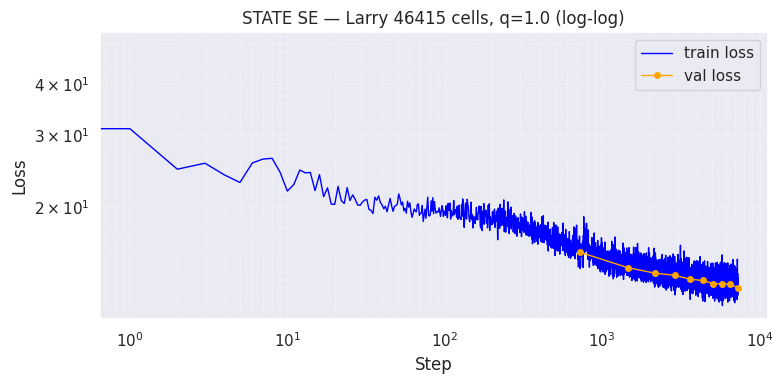

In [8]:
log_dirs = sorted(glob.glob(
    str(model.checkpoint_dir / f"state_{model.profile_name}" / "version_*")
))
metrics_file = Path(log_dirs[-1]) / "metrics.csv"
print(f"Reading: {metrics_file}")

df = pd.read_csv(metrics_file)
train_loss = df[["step", "trainer/train_loss"]].dropna()
val_loss = df[["step", "validation/val_loss"]].dropna()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    train_loss["step"], train_loss["trainer/train_loss"],
    label="train loss", color="blue", linewidth=1
)

ax.plot(
    val_loss["step"], val_loss["validation/val_loss"],
    color="orange", marker="o", label="val loss", markersize=4, linewidth=1
)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"STATE SE \u2014 Larry {SIZE} cells, q={QUALITY} (log-log)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3, which="both", linestyle='--')
fig.tight_layout()
plt.show()

## 4. Embed test set

In [9]:
embeddings = model.embed()
print(f"Embeddings shape: {embeddings.shape}")

  Using checkpoint: /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/checkpoints/state_scaling_larry_46415_1_0/exp_state_scaling_larry_46415_1_0_layers_3_dmodel_256_samples_2048_max_lr_0.0001_op_dim_256-epoch=9-step=7250.ckpt
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb transform --checkpoint /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/checkpoints/state_scaling_larry_46415_1_0/exp_state_scaling_larry_46415_1_0_layers_3_dmodel_256_samples_2048_max_lr_0.0001_op_dim_256-epoch=9-step=7250.ckpt --input /home/igor/noise_scaling/data/larry/test/1.0/preprocessed/preprocessed.h5ad --output /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/embeddings.npy


INFO:state._cli._emb._transform:Using model checkpoint: /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/checkpoints/state_scaling_larry_46415_1_0/exp_state_scaling_larry_46415_1_0_layers_3_dmodel_256_samples_2048_max_lr_0.0001_op_dim_256-epoch=9-step=7250.ckpt
INFO:state._cli._emb._transform:Creating inference object
INFO:state._cli._emb._transform:Loading model from checkpoint: /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/checkpoints/state_scaling_larry_46415_1_0/exp_state_scaling_larry_46415_1_0_layers_3_dmodel_256_samples_2048_max_lr_0.0001_op_dim_256-epoch=9-step=7250.ckpt
INFO:state._cli._emb._transform:Created output directory: /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model
INFO:state._cli._emb._transform:Computing embeddings for /home/igor/noise_scaling/data/larry/test/1.0/preprocessed/preprocessed.h5ad
INFO:state._cli._emb._transform:Output will be saved to /home/igor/noise_scaling/data/larry/46415/1.0/results/State/mode

!!! 18146 genes mapped to embedding file (out of 25289)


Encoding: 100%|██████████| 2046/2046 [08:41<00:00,  3.92it/s]
INFO:state._cli._emb._transform:Saved embeddings matrix with shape (130887, 256) to /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/embeddings.npy
INFO:state._cli._emb._transform:Embedding computation completed successfully!


  Embeddings: (130887, 256)
Embeddings shape: (130887, 256)


## 5. Compute LMI mutual information (clone signal)

In [10]:
mi_results = model.mutual_information(max_epochs=300)
print("\nLMI results:")
for signal, mi in mi_results.items():
    print(f"  {signal}: {mi:.5f}")

Using GPU for LMI computation (device 3 visible as cuda:0)
Found 4 quality-specific signal files: ['Y_clone_1.0.csv', 'Y_clone_1.0_geneformer.csv', 'Y_index_1.0.csv', 'Y_time_1.0.csv']
using signal file /home/igor/noise_scaling/data/larry/test/1.0/signals/Y_clone_1.0.csv
epoch 149 (of max 300) 🌻🌻🌻🌻 🎉🎉
success! training stopped at epoch 149
final validation loss: 1.652065634727478
State MI for Y_clone_1.0 at larry quality 1.0 size 46415: 0.9307211192229349
Saving results to /home/igor/noise_scaling/data/larry/46415/1.0/results/State/model/MI/42/Y_clone_1.0
using signal file /home/igor/noise_scaling/data/larry/test/1.0/signals/Y_index_1.0.csv
using signal file /home/igor/noise_scaling/data/larry/test/1.0/signals/Y_time_1.0.csv

LMI results:
  Y_clone_1.0.csv: 0.93072


## 6. Compare LMI across methods

In [11]:
results_root = base_dir / "results"
algos = ["PCA", "RandomProjection", "SCVI", "Geneformer", "State"]

rows = []
for algo in algos:
    sig = "Y_clone_1.0_geneformer" if algo == "Geneformer" else "Y_clone_1.0"
    mi_base = results_root / algo / "model" / "MI"
    if not mi_base.exists():
        print(f"{algo:20s}  NOT FOUND")
        continue
    for seed_dir in sorted(mi_base.iterdir()):
        mi_file = seed_dir / sig / "lmi_mutual_information.txt"
        if mi_file.exists():
            mi = float(mi_file.read_text().strip())
            rows.append({"Algorithm": algo, "seed": int(seed_dir.name), "LMI (clone)": mi})
            print(f"{algo:20s}  seed={seed_dir.name}  {mi:.5f}")

scores = pd.DataFrame(rows)
scores_agg = (
    scores.groupby("Algorithm")["LMI (clone)"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "mean_lmi", "std": "std_lmi", "count": "n_seeds"})
    .reset_index()
    .sort_values("mean_lmi", ascending=False)
)
scores_agg["std_lmi"] = scores_agg["std_lmi"].fillna(0)
scores_agg

PCA                   seed=1404  1.53782
PCA                   seed=2701  1.46364
PCA                   seed=42  1.42614
RandomProjection      seed=1404  0.40201
RandomProjection      seed=2701  0.40201
RandomProjection      seed=42  0.40201
SCVI                  seed=1404  1.80240
SCVI                  seed=2701  1.67760
SCVI                  seed=42  1.69718
Geneformer            seed=1404  0.65608
Geneformer            seed=2701  0.97136
Geneformer            seed=42  0.68506
State                 seed=42  0.93072


,Algorithm,mean_lmi,std_lmi,n_seeds
3,SCVI,1.725727,0.067119,3
1,PCA,1.475867,0.056835,3
4,State,0.930720,0.000000,1
0,Geneformer,0.770833,0.174265,3
2,RandomProjection,0.402010,0.000000,3


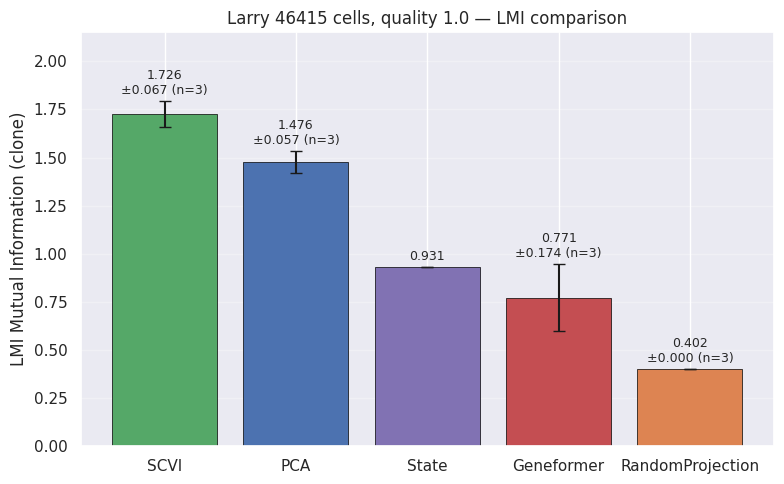

In [12]:
colors = {"PCA": "#4C72B0", "RandomProjection": "#DD8452",
          "SCVI": "#55A868", "Geneformer": "#C44E52", "State": "#8172B3"}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    scores_agg["Algorithm"], scores_agg["mean_lmi"],
    yerr=scores_agg["std_lmi"],
    capsize=4,
    color=[colors.get(a, "#999") for a in scores_agg["Algorithm"]],
    edgecolor="black", linewidth=0.5,
)

for bar, mean, std, n in zip(bars, scores_agg["mean_lmi"], scores_agg["std_lmi"], scores_agg["n_seeds"]):
    label = f"{mean:.3f}"
    if n > 1:
        label += f"\n\u00b1{std:.3f} (n={n})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.02,
            label, ha="center", va="bottom", fontsize=9)

ax.set_ylabel("LMI Mutual Information (clone)")
ax.set_title(f"Larry {SIZE} cells, quality {QUALITY} \u2014 LMI comparison")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, (scores_agg["mean_lmi"] + scores_agg["std_lmi"]).max() * 1.2)
fig.tight_layout()
plt.show()

## 7. UMAP of State embeddings

Running UMAP on 10000 cells, 256 dims


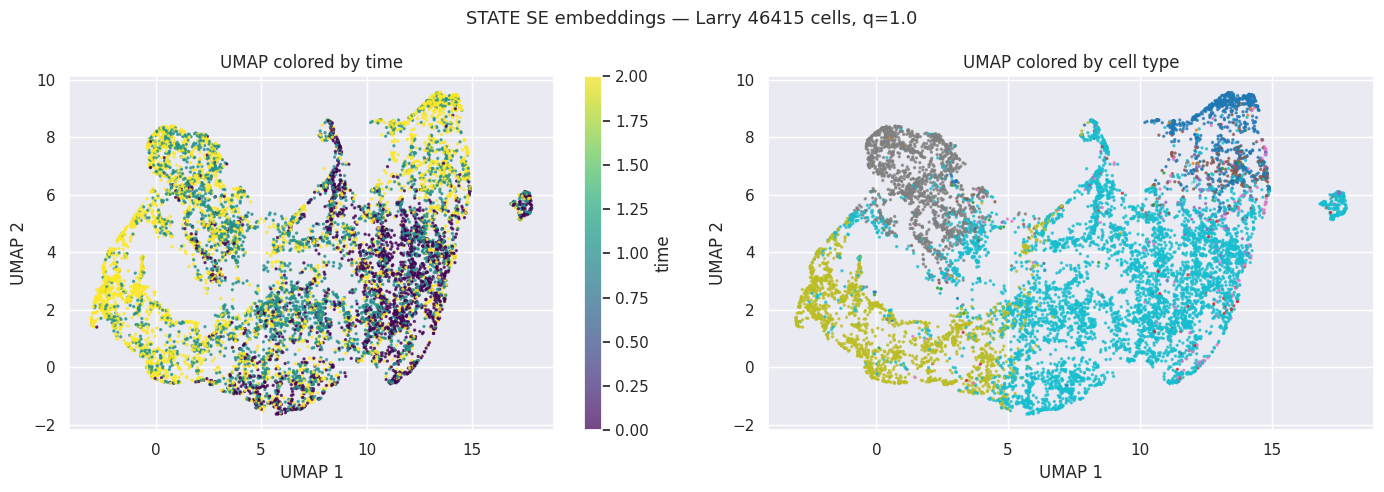

In [13]:
test_h5ad = model.test_data_path / "preprocessed.h5ad"
adata_test = ad.read_h5ad(test_h5ad)

max_cells = 10_000
if embeddings.shape[0] > max_cells:
    rng = np.random.default_rng(42)
    idx = rng.choice(embeddings.shape[0], max_cells, replace=False)
    emb_sub = embeddings[idx]
    obs_sub = adata_test.obs.iloc[idx]
else:
    emb_sub = embeddings
    obs_sub = adata_test.obs

print(f"Running UMAP on {emb_sub.shape[0]} cells, {emb_sub.shape[1]} dims")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
umap_coords = reducer.fit_transform(emb_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by time point
time_vals = obs_sub["time"].astype("category")
time_codes = time_vals.cat.codes.values
sc0 = axes[0].scatter(umap_coords[:, 0], umap_coords[:, 1],
                       c=time_codes, cmap="viridis", s=2, alpha=0.7)
axes[0].set_title("UMAP colored by time")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
plt.colorbar(sc0, ax=axes[0], label="time")

# Color by cell type
ct = obs_sub["type"].astype("category")
ct_codes = ct.cat.codes.values
sc1 = axes[1].scatter(umap_coords[:, 0], umap_coords[:, 1],
                       c=ct_codes, cmap="tab20", s=2, alpha=0.7)
axes[1].set_title("UMAP colored by cell type")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")

fig.suptitle(f"STATE SE embeddings \u2014 Larry {SIZE} cells, q={QUALITY}", fontsize=13)
fig.tight_layout()
plt.show()